# Inspect a generated scene

Phase 1 sanity-checking: build one T-joint, look at the numbers, plot the cloud and the
three D19 seam curves.

Run from the repo root (`weld_generator/`).

In [1]:
import sys, numpy as np
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/

from weldgen.config import load_config
from weldgen.scene import generate_scene

cfg = load_config("../configs/reference_tjoint.yaml")
scene, arrays = generate_scene(cfg, seed=8412337)

print("scene_id ", scene["scene_id"])
print("twin_key ", scene["twin_key"])
print("quality  ", scene["joint"]["quality_level"])
print("included ", round(scene["joint"]["included_angle_deg"], 3), "deg")
print("root gap ", round(scene["fit"]["root_gap_mm"], 3), "mm")
print("points   ", scene["cloud"]["n_points"])

scene_id  c13d4a46-0008412337
twin_key  ed448bd257deeafd
quality   C
included  90.0 deg
root gap  1.1 mm
points    15176


## Seams

A T-joint has two fillets (D5). `included_angle_deg` is one number for the scene, but the
two seams carry *different* dihedrals summing to 180 — that is D18's point that the two
quantities are not interchangeable.

In [2]:
for s in scene["seams"]:
    print(f'seam {s["id"]}  {s["face_pair"]}  len={s["length_mm"]:8.3f} mm  '
          f'dihedral={s["dihedral_deg"]:6.2f}  weldable={s["weldable"]}')

seam 0  ['A:+w', 'B:+w']  len= 232.000 mm  dihedral= 90.00  weldable=True
seam 1  ['A:+w', 'B:-w']  len= 232.000 mm  dihedral= 90.00  weldable=True


## D19: the three seam definitions

The stored curve is `nominal`. `root` and `gap_mid` ship as derived arrays so the
conversion is a subtraction, not a re-derivation. At a right angle the offsets are
`0`, `g/2`, `g` — but that closed form does not survive a sampled included angle.

In [3]:
g = scene["fit"]["root_gap_mm"]
for s in scene["seams"]:
    i = s["id"]
    nom = arrays[f"seams.npz:seam_{i}"]
    root = arrays[f"seams.npz:seam_{i}_root"]
    mid  = arrays[f"seams.npz:seam_{i}_gapmid"]
    print(f'seam {i}:  |root-nom| = {np.linalg.norm(root[0]-nom[0]):.4f}   '
          f'|mid-nom| = {np.linalg.norm(mid[0]-nom[0]):.4f}   (g = {g:.4f})')

seam 0:  |root-nom| = 1.1000   |mid-nom| = 0.5500   (g = 1.1000)
seam 1:  |root-nom| = 1.1000   |mid-nom| = 0.5500   (g = 1.1000)


## Plot

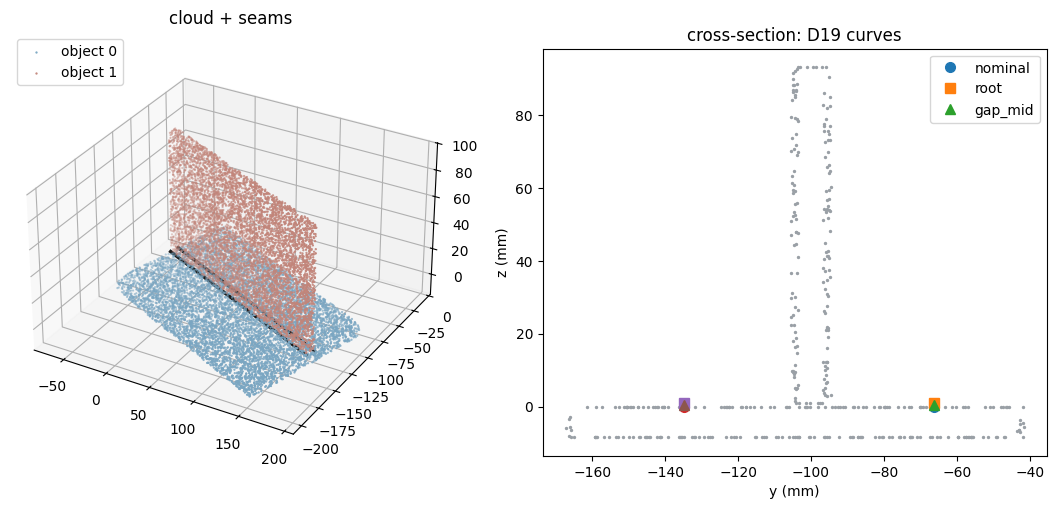

In [6]:
import matplotlib.pyplot as plt

xyz = arrays["cloud.npz:xyz"]
oid = arrays["cloud.npz:object_id"]

fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(121, projection="3d")
for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
    m = oid == o
    ax.scatter(xyz[m, 0], xyz[m, 1], xyz[m, 2], s=0.4, c=c, label=f"object {o}")
for s in scene["seams"]:
    p = arrays[f'seams.npz:seam_{s["id"]}']
    ax.plot(p[:, 0], p[:, 1], p[:, 2], lw=2.5, c="#1a1a1a")
ax.set_box_aspect([1, 1, 0.6]); ax.legend(loc="upper left"); ax.set_title("cloud + seams")

# Cross-section through the joint: the gap and the three curves are visible here.
ax2 = fig.add_subplot(122)
band = np.abs(xyz[:, 0] - np.median(xyz[:, 0])) < 3.0
ax2.scatter(xyz[band, 1], xyz[band, 2], s=2, c="#9aa0a6")
for s in scene["seams"]:
    i = s["id"]
    for key, style, lab in (("", "o", "nominal"), ("_root", "s", "root"), ("_gapmid", "^", "gap_mid")):
        p = arrays[f"seams.npz:seam_{i}{key}"]
        ax2.plot(p[0, 1], p[0, 2], style, ms=7, label=lab if i == 0 else None)
ax2.set_aspect("equal"); ax2.set_xlabel("y (mm)"); ax2.set_ylabel("z (mm)")
ax2.legend(); ax2.set_title("cross-section: D19 curves")
plt.tight_layout()

## Determinism

The Phase 1 gate (D15). The content hash is defined on *content*, not file bytes —
`np.savez` embeds zip timestamps, so byte-identity is unachievable.

In [5]:
from weldgen.hashing import content_hash

a = content_hash(*generate_scene(cfg, 8412337))
b = content_hash(*generate_scene(cfg, 8412337))
print(a)
print("repeatable:", a == b)

# provenance is excluded, so re-running next month still matches
sc, ar = generate_scene(cfg, 8412337)
sc["provenance"]["created_utc"] = "1999-01-01T00:00:00Z"
print("provenance-independent:", content_hash(sc, ar) == a)

ce30ab243ea902c2946f2c4b88e7f0cfc88ac1bcb90dd94ddf90a417e2fae140
repeatable: True
provenance-independent: True
